In [ ]:
from main.scheduler import EDMScheduler
import matplotlib.pyplot as plt

from omegaconf import OmegaConf
import torch

In [ ]:
num_steps = 5
edmsampler1 = EDMScheduler(num_steps)
t = edmsampler1.get_discrete_time_steps(num_steps)
sigma = edmsampler1.get_sigma(t)
plt.plot(t)

In [ ]:
#Load a scheduler using a config file
daps_config_yaml = 'configs/daps_config/edm_daps.yaml'
daps_config = OmegaConf.load(daps_config_yaml)

In [100]:
import torch
from diffusers import UNet2DModel, DDPMScheduler
from models import DiffusionModel, register_model

@register_model(name='ddpm-celebahq-256')
class MyDDPMModel(DiffusionModel):
    def __init__(self):
        """
        Wrapper for google/ddpm-celebahq-256.
        Handles the mismatch between Continuous ODE Solvers (high sigma) 
        and Discrete DDPM Models (sigma <= 1).
        """
        super().__init__()
        model_id = "google/ddpm-celebahq-256"
        
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.unet = UNet2DModel.from_pretrained(model_id)
        self.unet.to(self.device)
        self.unet.eval()

        self.scheduler = DDPMScheduler.from_pretrained(model_id)
        self.alphas_cumprod = self.scheduler.alphas_cumprod.to(self.device)
        
        self.sigmas = torch.sqrt(1 - self.alphas_cumprod)

    def _get_timestep_from_sigma(self, sigma):
        """
        Robust mapping from continuous sigma to discrete timestep t.
        """
        # Ensure sigma is a tensor on the correct device
        if not torch.is_tensor(sigma):
            sigma = torch.tensor(sigma, device=self.device)
        else:
            sigma = sigma.to(self.device)

        if sigma > self.sigmas.max():
            return torch.tensor(self.scheduler.config.num_train_timesteps - 1, device=self.device)
            
        diff = torch.abs(self.sigmas - sigma)
        t = torch.argmin(diff)
        return t

    def _scale_input(self, x, sigma):
        """
        Scales high-variance input (from ODE solver) to unit-variance (expected by DDPM).
        Assumption: Solver uses VE-like scaling (x ~ x0 + sigma*eps).
        DDPM expects: x ~ sqrt(alpha)*x0 + sqrt(1-alpha)*eps.
        
        Approximation: x_ddpm = x_solver / sqrt(sigma^2 + 1)
        """
        scale_factor = torch.sqrt(sigma**2 + 1)
        return x / scale_factor

    def tweedie(self, x, sigma):
        """
        Computes the Score Function \nabla_{x_t} log p(x_t; sigma_t).
        Note: The docstring asks for Score Function here.
        """
        t = self._get_timestep_from_sigma(sigma)
        x = x.to(self.device)
        
        x_in = self._scale_input(x, sigma)
        
        with torch.no_grad():
            epsilon = self.unet(x_in, t).sample
            
        score = -epsilon / sigma
        return score

    def score(self, x, sigma):
        """
        Computes the expected clean data (x0 estimate).
        Note: The docstring asks for Clean Data Estimate here.
        """
        t = self._get_timestep_from_sigma(sigma)
        x = x.to(self.device)
        
        x_in = self._scale_input(x, sigma)
        
        with torch.no_grad():
            epsilon = self.unet(x_in, t).sample

        alpha_bar = self.alphas_cumprod[t]
                
        beta_coeff = torch.sqrt(1 - alpha_bar)
        alpha_coeff = torch.sqrt(alpha_bar)
        
        if alpha_coeff < 1e-5:
            return torch.zeros_like(x)
            
        x0_estimate = (x_in - (beta_coeff * epsilon)) / alpha_coeff
        
        return x0_estimate

    def get_in_shape(self):
        """Return the shape of the model's input data."""
        return (3, 256, 256)
            
model = MyDDPMModel()

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [101]:
import torch
from data import DiffusionData, register_dataset
import torchvision.transforms as transforms
from datasets import load_dataset

@register_dataset(name='my_dataset')
class MyDataset(DiffusionData):
    def __init__(self, split="validation"):
        """
        Initializes the CelebA-HQ dataset from Hugging Face.
        
        Args:
            split (str): The dataset split to load (e.g., 'train', 'val'). 
                         Defaults to 'train'.
        """
        super().__init__()
        
        try:
            self.dataset = load_dataset("korexyz/celeba-hq-256x256", split=split)
        except Exception as e:
            print(f"Error loading dataset: {e}")
            raise

        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __getitem__(self, idx):
        """
        Retrieves an image by index and applies transformations.
        
        Args:
            idx (int): Index of the dataset item.
            
        Returns:
            torch.Tensor: Preprocessed image tensor of shape (3, 256, 256).
        """

        data_item = self.dataset[idx]
        image = data_item['image']

        # Ensure image is RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

    def __len__(self):
        """
        Returns the total length of the dataset.
        """
        return len(self.dataset)

    def get_shape(self):
        """
        Returns the shape of the data: (Channels, Height, Width).
        """
        return (3, 256, 256)

In [102]:
dataset = MyDataset()

In [103]:
images = dataset.get_data(5)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90588236..0.9529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


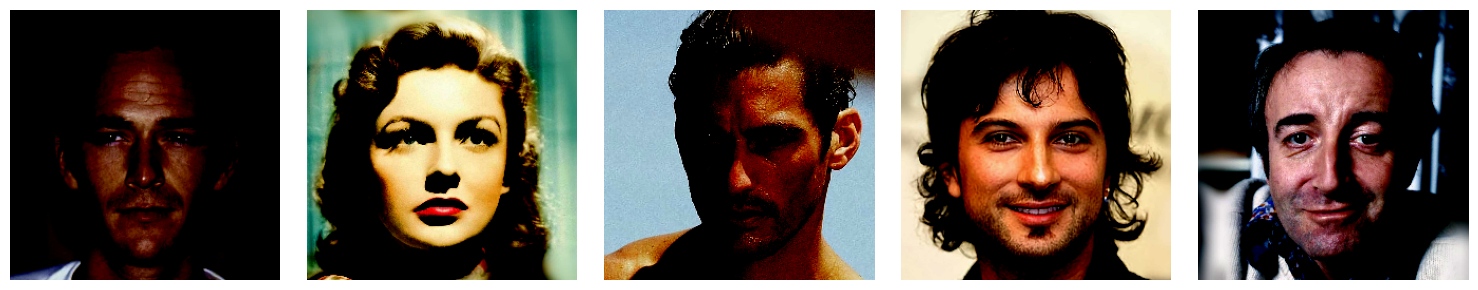

In [104]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))  # 1 row, 5 columns

for i, ax in enumerate(axs):
    img_np = images[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img_np)       
    ax.axis('off')             

plt.tight_layout()
plt.show()

In [105]:
from torchvision.utils import save_image
import PIL
def visualize_grid(images, target='image.png', nrow=10, figsize=None, normalize=True):
    # Save images.
    save_grid(images, target, nrow=nrow, normalize=normalize)
    visualize_pil(target, figsize=figsize)


def save_grid(images, target='image.png', nrow=10, normalize=True):
    # Save images.
    if normalize:
        images = norm_image_01(images)
    save_image(images, target, nrow=nrow)

def norm_image_01(x):
    return (x * 0.5 + 0.5).clip(0, 1)

def visualize_pil(target, figsize=None):
    pil_image = PIL.Image.open(target)
    if figsize is None:
        plt.figure(figsize=(24, 24))
    else:
        plt.figure(figsize=figsize)
    plt.imshow(pil_image)
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()




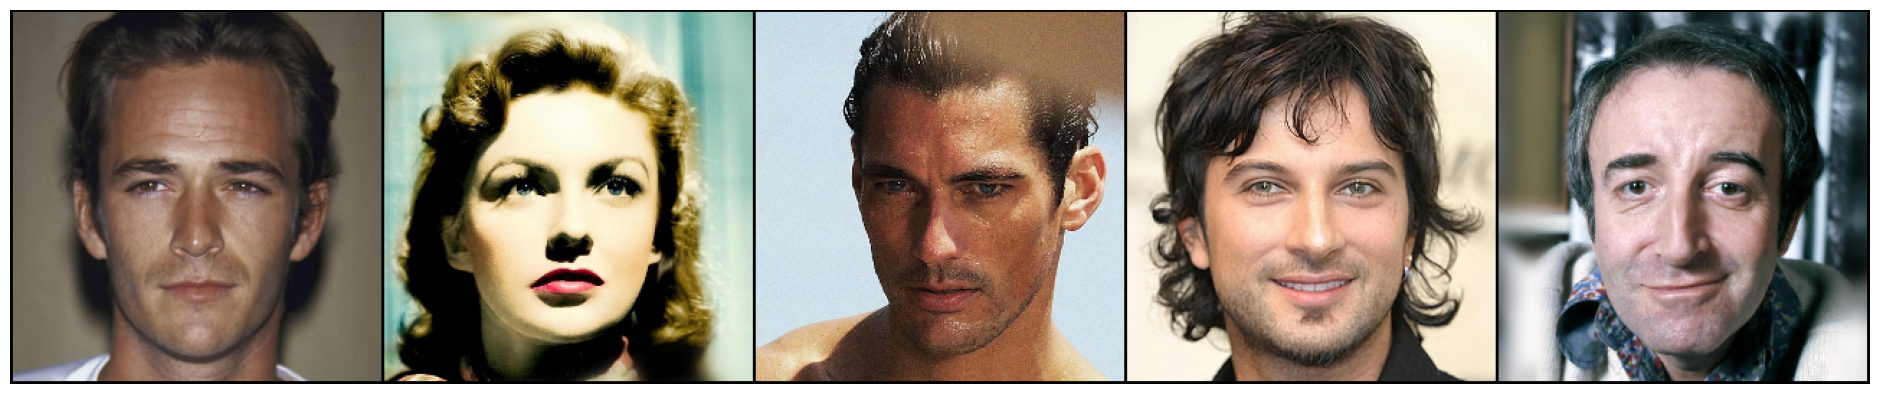

In [106]:
visualize_grid(images, nrow=10)

In [107]:
model.get_in_shape()

(3, 256, 256)

In [108]:
#To check how odeint works
from torchdiffeq import odeint
def f(t,x):
    return t
time_step = torch.tensor([0.0, 5.0])
x0 = torch.tensor(0, dtype=torch.float32)
x_T = odeint(f,x0,  time_step)
x_T


tensor([ 0.0000, 12.5000])

In [109]:
img1 = images[0]
img1.shape

torch.Size([3, 256, 256])

In [110]:
#To check if pfode.py is working
from main.pfode import PFODE
pf_ode = PFODE(edmsampler1, model, (5, *img1.shape))
x_T = pf_ode.gaussian_prior_x_T(5)
x_0 = pf_ode.solve(x_T)

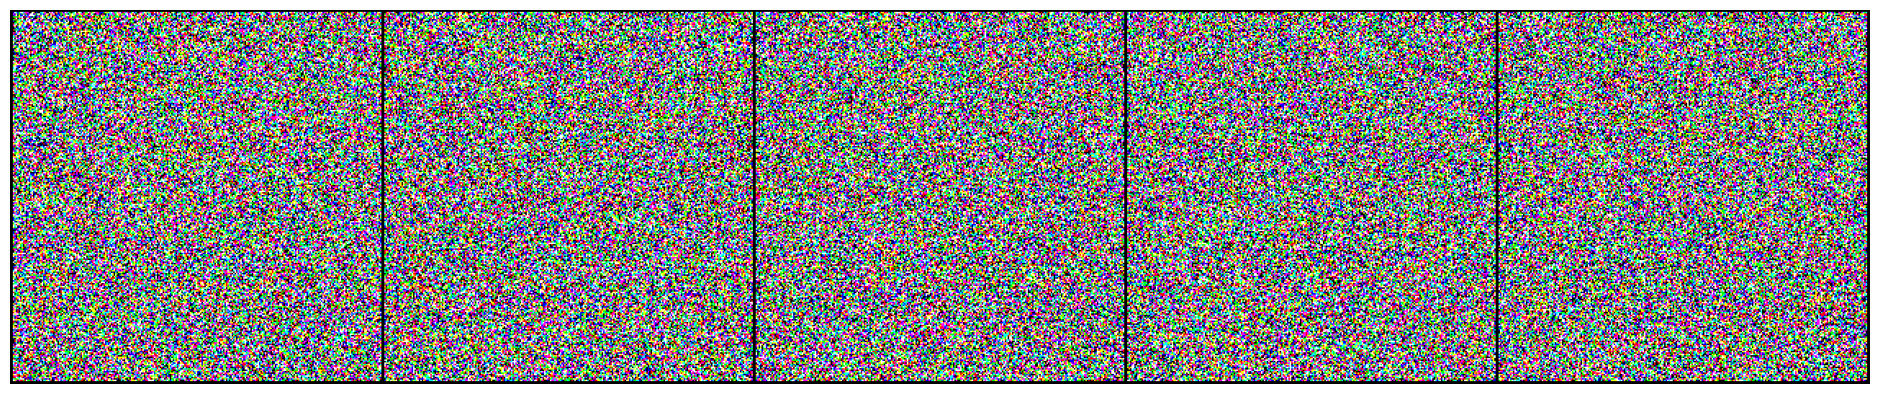

In [111]:
visualize_grid(x_T, nrow=5)

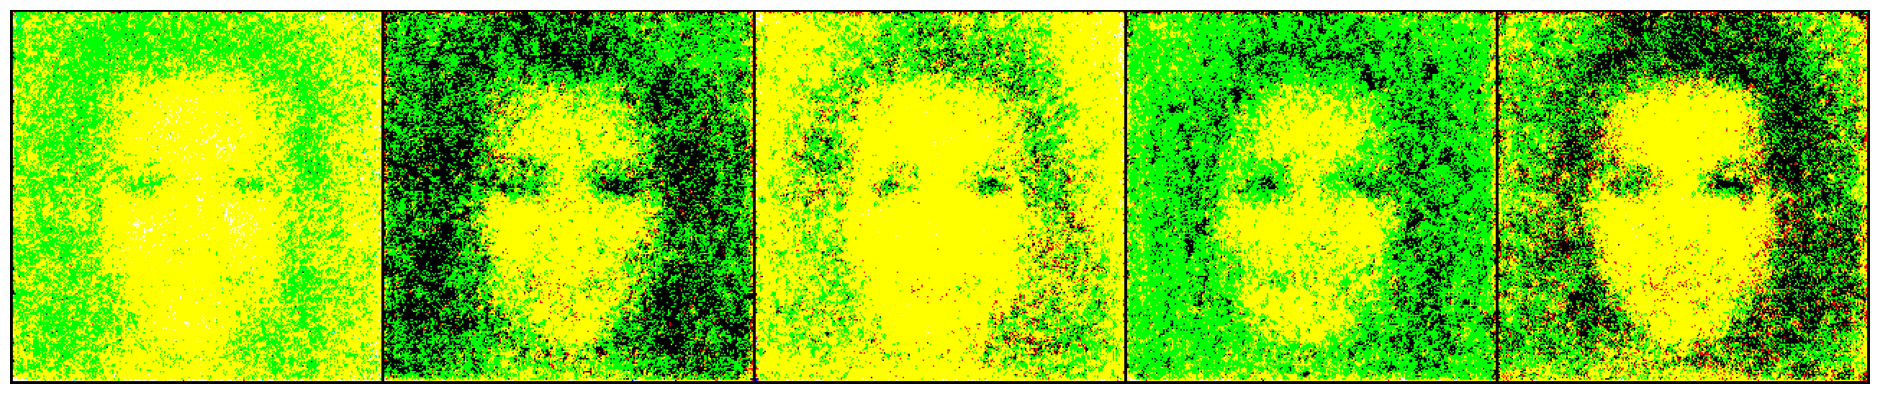

In [112]:
visualize_grid(x_0, nrow=5)

In [113]:
#Load an operator using a config file
task_config_yaml = 'configs/task/phase_retrieval.yaml'
task_group = 'pixel'
task_config = OmegaConf.load(task_config_yaml)
mcmc_sampler_config = task_config[task_group].mcmc_sampler_config
operator_config = task_config[task_group].operator


In [114]:
mcmc_sampler_config

{'num_steps': 100, 'lr': 5e-05, 'tau': 0.01, 'lr_min_ratio': 0.01, 'mc_algo': 'langevin', 'prior_solver': 'gaussian'}

In [115]:
from forward_operator import get_operator
operator = get_operator(**operator_config)
measurement = operator.measure(images)

In [116]:
from torch.nn.functional import interpolate

def resize(y, x, task_name):
    if y.shape != x.shape:
        ry = interpolate(y, size=x.shape[-2:], mode='bilinear', align_corners=False)
    else:
        ry = y
    if task_name == 'phase_retrieval':
        def norm_01(y):
            tmp = (y - y.mean()) / y.std()
            tmp = tmp.clip(-0.5, 0.5) * 3
            return tmp

        ry = norm_01(ry) * 2 - 1
    return ry

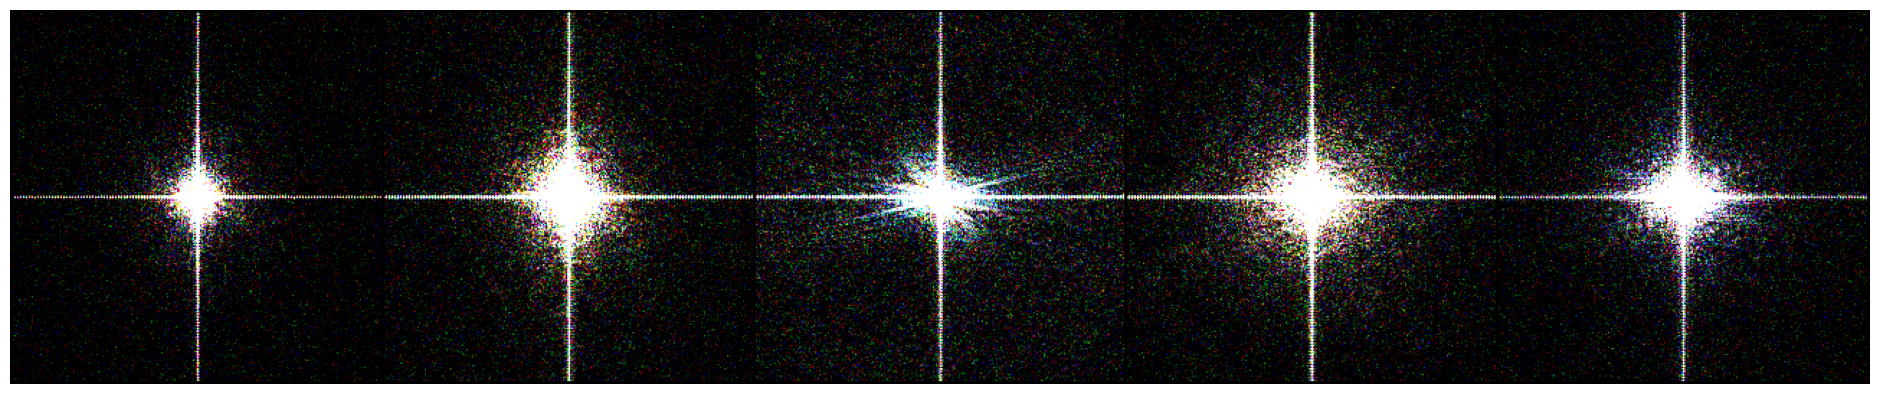

In [117]:
#Measurement works
resized_measurement = resize(measurement, images, operator_config.name)
visualize_grid(resized_measurement, nrow=5)

In [118]:
x_0.requires_grad
x_0_rq_grad = x_0.clone().detach().requires_grad_(True)
x_0_rq_grad.requires_grad

True

In [119]:
#To check if Langevian is working
from daps_sampler import MCMC_Langevin

mcmc_lv = MCMC_Langevin(eta = mcmc_sampler_config['lr'], beta_y = mcmc_sampler_config['tau'], iter = mcmc_sampler_config['num_steps'])
x0_cond, x0_cond_list = mcmc_lv.mcmc_chain(x0_hat= x_0, measurement=measurement.to("cuda"), operator=operator, r_t = 100)


100%|████████████████████████████████████████| 100/100 [00:00<00:00, 204.65it/s]


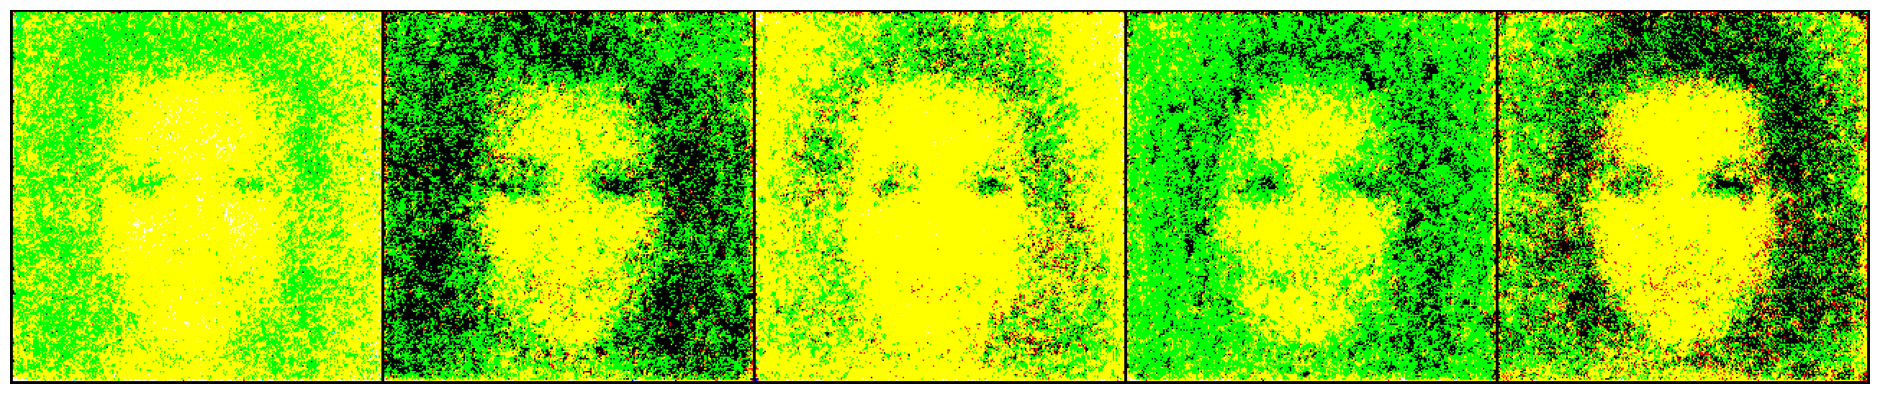

In [120]:
visualize_grid(x0_cond, nrow=5)

In [121]:
daps_config

{'latent': False, 'annealing_scheduler_config': {'name': 'edm', 'num_steps': 200, 'sigma_max': 100, 'sigma_min': 0.1, 'timestep': 'poly-7'}, 'diffusion_scheduler_config': {'name': 'edm', 'num_steps': 5, 'sigma_min': 0.01, 'timestep': 'poly-7'}}

In [122]:
#To check if DAPS is working
from daps_sampler import DAPS
daps = DAPS(daps_config['annealing_scheduler_config'], daps_config['diffusion_scheduler_config'], mcmc_sampler_config)
x_init = pf_ode.gaussian_prior_x_T(5)
x_final = daps.daps_sample(model, x_init, operator, measurement.to("cuda"))

100%|█████████████████████████████████████████| 200/200 [10:45<00:00,  3.23s/it]


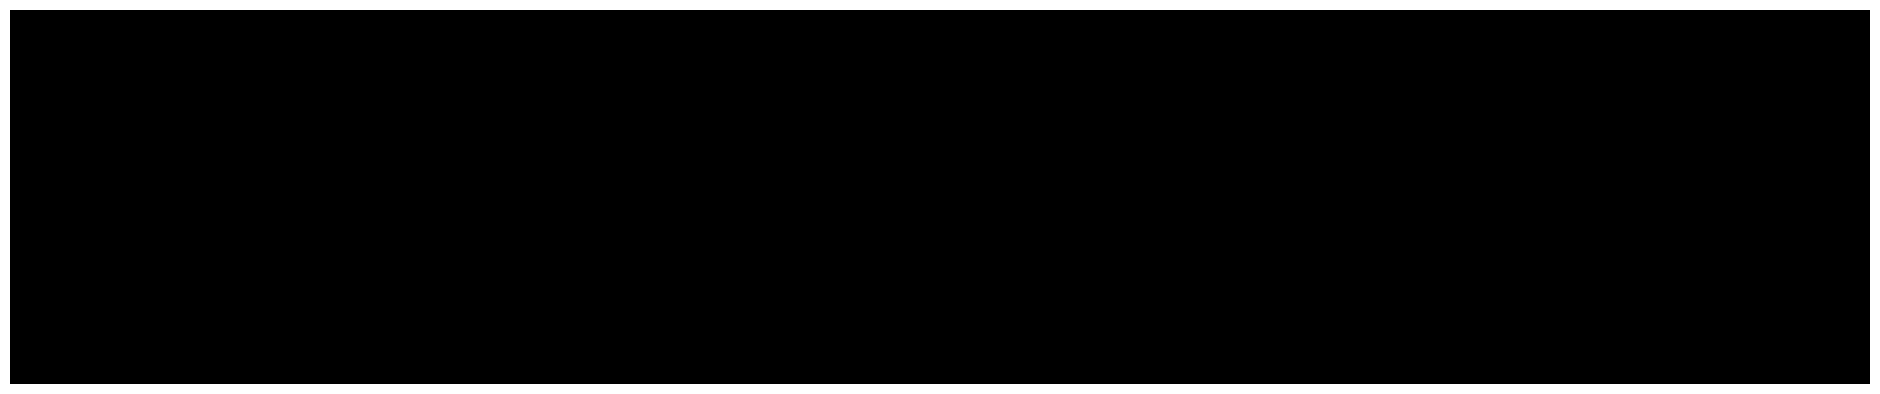

In [124]:
visualize_grid(x_final, nrow=5)